<a href="https://colab.research.google.com/github/viniciusarnom/estudo_dirigido/blob/main/C%C3%B3digo%20para%20Random%20Forest%20DAY%201.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Carregando BES...
Carregando MEB...
Carregando BROWNING...
Carregando HONORS...

Distribuição das classes:
label
BES         100000
MEB         100000
BROWNING     85950
HONORS       76773
Name: count, dtype: int64

Tamanhos:
Treino: 217633 (60.00%)
Teste: 72545 (20.00%)
Validação: 72545 (20.00%)

Treinando modelo...

=== VALIDAÇÃO ===
Acurácia: 0.8197
Precisão (Macro): 0.8344
Recall (Macro): 0.8295
F1-score (Macro): 0.8269

=== TESTE FINAL ===
Acurácia: 0.8212
Precisão (Macro): 0.8362
Recall (Macro): 0.8309
F1-score (Macro): 0.8283

Relatório completo:
              precision    recall  f1-score   support

         BES       0.81      0.66      0.73     20000
    BROWNING       0.97      0.85      0.91     17190
      HONORS       0.86      0.97      0.91     15355
         MEB       0.71      0.84      0.77     20000

    accuracy                           0.82     72545
   macro avg       0.84      0.83      0.83     72545
weighted avg       0.83      0.82      0.82     72545



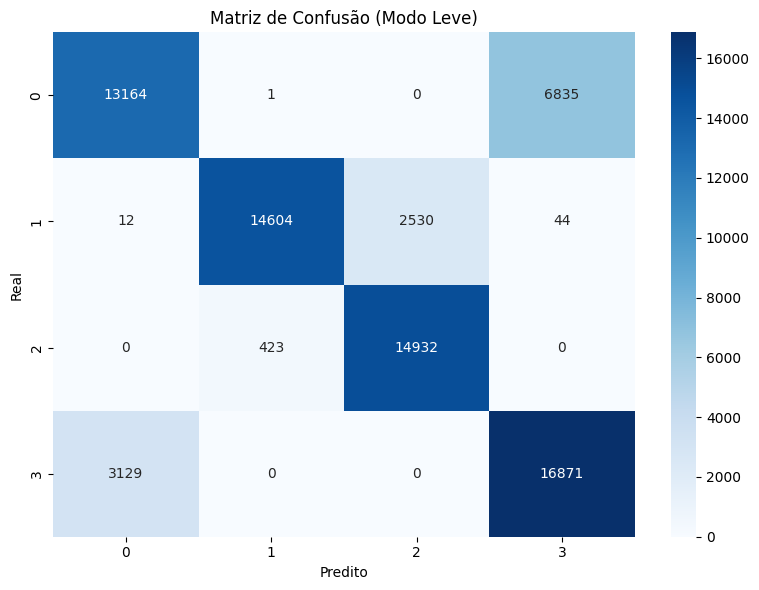

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    f1_score,
    precision_score,
    recall_score
)

# ======================================================
# CONFIGURAÇÃO (controle de memória)
# ======================================================
MAX_AMOSTRAS_POR_ARQUIVO = 100000  # ajuste conforme sua RAM

# ======================================================
# 1. CARREGAMENTO OTIMIZADO
# ======================================================
def carregar_dados_leve(caminho_arquivo, label_str):
    with open(caminho_arquivo, 'rb') as f:
        _ = f.read(3)
        dados = np.fromfile(f, dtype=np.float32)

    # Garantir múltiplo de 3
    sobra = dados.size % 3
    if sobra != 0:
        dados = dados[:dados.size - sobra]

    dados = dados.reshape(-1, 3)

    # Redução de amostras
    if len(dados) > MAX_AMOSTRAS_POR_ARQUIVO:
        idx = np.random.choice(len(dados), MAX_AMOSTRAS_POR_ARQUIVO, replace=False)
        dados = dados[idx]

    df = pd.DataFrame(dados, columns=['I', 'Q', 'Magnitude'], dtype=np.float32)

    # Recalcular Magnitude (mais seguro)
    df['Magnitude'] = np.sqrt(df['I']**2 + df['Q']**2)

    # Limpeza
    df = df.replace([np.inf, -np.inf], np.nan).dropna()

    df['label'] = label_str

    return df

# ======================================================
# 2. LEITURA DOS ARQUIVOS
# ======================================================
arquivos = {
    "BES": 'concatenado_Day_1_bes_completo.bin',
    "MEB": 'concatenado_Day_1_meb_completo.bin',
    "BROWNING": 'concatenado_Day_1_browning_completo.bin',
    "HONORS": 'concatenado_Day_1_honors_completo.bin'
}

df_lista = []

for label, path in arquivos.items():
    try:
        print(f"Carregando {label}...")
        df_lista.append(carregar_dados_leve(path, label))
    except Exception as e:
        print(f"Erro em {label}: {e}")

if not df_lista:
    raise ValueError("Nenhum dado carregado.")

# ======================================================
# 3. DATASET FINAL
# ======================================================
df_final = pd.concat(df_lista, ignore_index=True)

# Limpeza final
df_final = df_final.replace([np.inf, -np.inf], np.nan)
df_final = df_final.dropna()
df_final = df_final.reset_index(drop=True)

# Validação
if not np.isfinite(df_final[['I', 'Q', 'Magnitude']].values).all():
    raise ValueError("Ainda existem valores inválidos!")

# Features e target
X = df_final[['I', 'Q', 'Magnitude']].astype(np.float32)
y = df_final['label']

print("\nDistribuição das classes:")
print(y.value_counts())

# ======================================================
# 4. SPLIT 60% TREINO | 20% TESTE | 20% VALIDAÇÃO
# ======================================================
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.4,
    random_state=42,
    stratify=y
)

X_test, X_val, y_test, y_val = train_test_split(
    X_temp, y_temp,
    test_size=0.5,
    random_state=42,
    stratify=y_temp
)

print(f"\nTamanhos:")
print(f"Treino: {len(X_train)} ({len(X_train)/len(X):.2%})")
print(f"Teste: {len(X_test)} ({len(X_test)/len(X):.2%})")
print(f"Validação: {len(X_val)} ({len(X_val)/len(X):.2%})")

# ======================================================
# 5. MODELO LEVE
# ======================================================
rf_model = RandomForestClassifier(
    n_estimators=50,
    max_depth=15,
    min_samples_split=10,
    min_samples_leaf=4,
    n_jobs=-1,
    random_state=42
)

print("\nTreinando modelo...")
rf_model.fit(X_train, y_train)

# ======================================================
# 6. AVALIAÇÃO (VALIDAÇÃO)
# ======================================================
y_val_pred = rf_model.predict(X_val)

print("\n=== VALIDAÇÃO ===")
print(f"Acurácia: {accuracy_score(y_val, y_val_pred):.4f}")
print(f"Precisão (Macro): {precision_score(y_val, y_val_pred, average='macro'):.4f}")
print(f"Recall (Macro): {recall_score(y_val, y_val_pred, average='macro'):.4f}")
print(f"F1-score (Macro): {f1_score(y_val, y_val_pred, average='macro'):.4f}")

# ======================================================
# 7. AVALIAÇÃO FINAL (TESTE)
# ======================================================
y_pred = rf_model.predict(X_test)

print("\n=== TESTE FINAL ===")
print(f"Acurácia: {accuracy_score(y_test, y_pred):.4f}")
print(f"Precisão (Macro): {precision_score(y_test, y_pred, average='macro'):.4f}")
print(f"Recall (Macro): {recall_score(y_test, y_pred, average='macro'):.4f}")
print(f"F1-score (Macro): {f1_score(y_test, y_pred, average='macro'):.4f}")

print("\nRelatório completo:")
print(classification_report(y_test, y_pred))

# ======================================================
# 8. MATRIZ DE CONFUSÃO
# ======================================================
plt.figure(figsize=(8, 6))

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("Matriz de Confusão (Modo Leve)")
plt.xlabel("Predito")
plt.ylabel("Real")

plt.tight_layout()
plt.show()